In [18]:
#imports/dependencies
%pip install langgraph langchain langchain-openAI tavily-python graphviz matplotlib


In [19]:
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
#create users, availability, appointments csvs
users_df = pd.DataFrame([
    {"user_id": "user_123", "patient_name": "Tendai Ball", "date_of_birth": "2003-01-01", "phone": "555-1234"},
    {"user_id": "user_456", "patient_name": "Jane Doe", "date_of_birth": "1998-07-10", "phone": "555-9876"},
    {"user_id": "user_789", "patient_name": "John Smith", "date_of_birth": "1985-11-22", "phone": "555-2468"}
])

availability_df = pd.DataFrame([
    {"date": "2026-04-15", "specialty": "cardiology",  "time": "9:00 AM",  "is_available": 1},
    {"date": "2026-04-15", "specialty": "cardiology",  "time": "1:30 PM",  "is_available": 1},
    {"date": "2026-04-15", "specialty": "dermatology", "time": "10:00 AM", "is_available": 1},
    {"date": "2026-04-15", "specialty": "dermatology", "time": "3:00 PM",  "is_available": 1},
    {"date": "2026-04-16", "specialty": "cardiology",  "time": "11:00 AM", "is_available": 1},
    {"date": "2026-04-16", "specialty": "neurology",   "time": "2:00 PM",  "is_available": 1}
])

appointments_df = pd.DataFrame([
    {
        "appointment_id": "APT-1001",
        "user_id": "user_123",
        "patient_name": "Tendai Ball",
        "date": "2026-04-15",
        "specialty": "cardiology",
        "time": "9:00 AM",
        "status": "booked"
    }
])

users_df.to_csv("users.csv", index=False)
availability_df.to_csv("availability.csv", index=False)
appointments_df.to_csv("appointments.csv", index=False)

print("Created users.csv, availability.csv, and appointments.csv")

Created users.csv, availability.csv, and appointments.csv


In [22]:
from dotenv import load_dotenv
import os

# Specify the full path to your .env file
load_dotenv(r"C:\Users\Tendai\OneDrive\Chat Agents\.env")
openai_api_key = os.getenv("OPENAI_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [23]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model = 'gpt-4o-mini', temperature=0, openai_api_key=openai_api_key)

In [24]:
from dataclasses import dataclass, field
from typing import Literal

@dataclass
class BookingConfirmation:
    appointment_id: str = field(default="")
    user_id: str = field(default="")
    patient_name: str = field(default="")
    date: str = field(default="")
    specialty: str = field(default="")
    time: str = field(default="")
    status: Literal["booked", "pending", "cancelled"] = field(default="pending")

    def is_complete(self) -> bool:
        required = [self.appointment_id, self.user_id, 
                    self.patient_name, self.date, 
                    self.specialty, self.time]
        return all(required)

    def missing_fields(self) -> list[str]:
        checks = {
            "appointment_id": self.appointment_id,
            "user_id": self.user_id,
            "patient_name": self.patient_name,
            "date": self.date,
            "specialty": self.specialty,
            "time": self.time,
        }
        return [k for k, v in checks.items() if not v]

In [45]:
from langchain_core.tools import tool
from typing import TypedDict

# Custom state that includes booking confirmation
class AgentState(TypedDict):
    messages: list
    booking: BookingConfirmation

# Global booking variable for tools to use
booking = BookingConfirmation()

@tool
def get_user_id(patient_name: str) -> str:
    """Look up user ID from patient name."""
    db = pd.read_csv("users.csv")
    result = db.loc[db['patient_name'].str.lower() == patient_name.lower()]
    booking.user_id = result["user_id"]
    name = db.loc[db['user_id'] == result["user_id"]]
    booking.patient_name = name["patient_name"].iloc[0]
    return f"Found user_id: {result['user_id']}"

@tool
def generate_appointment_id() -> str:
    """Generate a unique appointment ID in format APPT_XXXX where XXXX are 4 digits."""
    import random

    # Read existing appointment IDs
    appointment_df = pd.read_csv("appointments.csv")
    existing_ids = set(appointment_df['appointment_id'].tolist()) if 'appointment_id' in appointment_df.columns else set()

    # Generate unique 4-digit number
    while True:
        # Generate 4-digit number (0000-9999)
        digits = f"{random.randint(0, 9999):04d}"
        appt_id = f"APPT_{digits}"

        # Check if unique
        if appt_id not in existing_ids:
            booking.appointment_id = appt_id
            return f"Generated appointment_id: {appt_id}"

@tool
def check_availability(specialty: str, date: str) -> str:
    """Check available time slots for a specialty on a given date."""
    if not specialty or not date:
        return "Specialty and date are required to check availability."
    calendar = pd.read_csv("availability.csv")
    slots = calendar[calendar['date'] == date & calendar['specialty'] == specialty]['time'].tolist()
    booking.specialty = specialty
    booking.date = date
    return f"Available slots: {slots}"

@tool
def confirm_slot(time: str) -> str:
    """Confirm and lock a time slot."""
    booking.time = time
    booking.status = "booked"
    return f"Slot confirmed at {time}"

@tool
def get_booking_status() -> str:
    """Check which fields are still missing from the booking."""
    missing = booking.missing_fields()
    if not missing:
        return "Booking is complete."
    return f"Still missing: {missing}"

@tool
def save_booking(booking: BookingConfirmation) -> str:
    """Save the booking to appointments.csv."""
    if not booking.is_complete():
        return "Cannot save incomplete booking. Missing fields: " + ", ".join(booking.missing_fields())
    
    new_entry = {
        "appointment_id": booking.appointment_id,
        "user_id": booking.user_id,
        "patient_name": booking.patient_name,
        "date": booking.date,
        "specialty": booking.specialty,
        "time": booking.time,
        "status": booking.status
    }
    df = pd.read_csv("appointments.csv")
    df = df.append(new_entry, ignore_index=True)
    df.to_csv("appointments.csv", index=False)
    return f"Booking saved with appointment_id: {booking.appointment_id}"

In [46]:
#bind tools
tools = [get_user_id, generate_appointment_id, check_availability, confirm_slot, get_booking_status, save_booking]
toolsbyname = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [47]:
#build nodes
from typing import Literal
import json
from langgraph.graph import MessagesState, START, END, StateGraph
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage
#initialize assistant system message
ASSISTANT_SYSTEM_MESSAGE = SystemMessage(content="You are a scheduling assistant. "
                                         "You help users book medical appointments using the provided tools."
                                         "you cannot give medical advice."
                                         "ask follow-up questions to get missing information before booking appointments.")

def llm_call (state: AgentState):
    """llm decides whether to call tool or not using messages state"""
    return {
        "messages": [llm_with_tools.invoke(
            [ASSISTANT_SYSTEM_MESSAGE] + state["messages"]
        )],
        "booking": state["booking"]
    }

def tool_node(state: AgentState):
    """performs tool call"""
    result = []
    global booking
    booking = state["booking"]  # Update global booking from state

    for tool_call in state["messages"][-1].tool_calls:
        tool = toolsbyname[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])

        if isinstance(observation, dict):
            observation = json.dumps(observation, indent=2)
        else:
            observation = str(observation)

        result.append(
            ToolMessage(
                content=observation,
                tool_call_id=tool_call["id"]
            )
        )

    return {"messages": result, "booking": booking}  # Return updated booking

def should_continue(state: AgentState) -> Literal["action", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "action"
    return END

In [48]:
from langgraph.checkpoint.memory import InMemorySaver
#build agent
agent_builder = StateGraph(AgentState)
#add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)
#add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "action":"environment",
        END: END
    }
)
agent_builder.add_edge("environment", "llm_call")
#compile
memory = InMemorySaver()
agent = agent_builder.compile(checkpointer=memory)

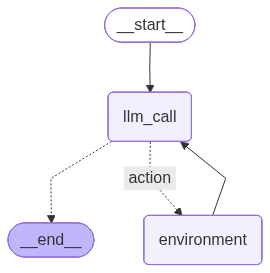

In [49]:
#display
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [50]:
from datetime import datetime
from pathlib import Path


SETTINGS = {
    "default_save_path": "conversation.json"
}

def serialize_message(msg):
    return {
        "type": msg.__class__.__name__,
        "content": str(msg.content),
    }

def save_thread_to_file(thread_id: str, save_path: str | None = None):
    path = save_path or f"{thread_id}.json"

    config = {"configurable": {"thread_id": thread_id}}
    state = agent.get_state(config).values

    payload = {
        "thread_id": thread_id,
        "messages": [serialize_message(m) for m in state["messages"]],
    }

    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
        
def chat(thread_id: str, user_text: str, save_path: str | None = None):
    config = {"configurable": {"thread_id": thread_id}}

    response = agent.invoke(
        {
            "messages": [HumanMessage(content=user_text)],
            "booking": BookingConfirmation()  # Initialize fresh booking for each thread
        },
        config=config
    )

    save_thread_to_file(thread_id, save_path)
    print(response["messages"][-1].content)

In [52]:
chat("thread_2", "my name is Jane Doe")

Deserializing unregistered type __main__.BookingConfirmation from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'BookingConfirmation')]


ValueError: Can only compare identically-labeled Series objects